# Graficador de dados de puxamento

Os dados necessários para fazer os gráficos são os disponibilizados pelo programa LabView da torre de puxamento de polímeros.

## Modo de uso

 - Coloque os dados da torre de polímero em uma pasta "Dados" no mesmo local deste código.
 - Rode o código

Os gráficos serão salvos numa pasta "Graficos" neste mesmo local.

#### **IMPORTANTE**

Os dados serão lidos em ordem "alfabética". Apesar disso, o arquivo da banda lixo é colocado em primeiro, uma vez que as letras minúsculas vêm antes das maiúsculas (ASCII). Tome cuidado ao renomear arquivos.

## Outros dados

Outros dados necessários para colocar nesse código são:

```
diametro_inicial
```
Diâmetro inicial da preforma. Necessário para calcular a razão entre diâmetros.


```
mudancas_temperatura
```
Momentos do puxamento (em minutos desde o início do feed) em que a temperatura foi modificada. Necessário para fazer as anotações com linhas verticais no gráfico de temperatura.


In [1]:
# Diâmetro inicial da preforma
diametro_inicial = 15

# Minutos desde o início do puxamento em que a temperatura foi mudada
# Deixe uma lista vazia [] para ignorar essas marcações
mudancas_temperatura = []

# Número de dados consecutivos para realizar uma média movel.
# APENAS USADO PARA OS GRÁFICOS.
# Qualquer desenvolvimento usando os dados será feito sem a média móvel.
#   Depois, se graficado, usa-se a média móvel para suavizar os dados
media_n = 20
def media_movel(dados):
    ret = np.cumsum(np.array(dados, dtype=float), dtype=float)
    ret[media_n:] = ret[media_n:] - ret[:-media_n]
    return ret[media_n - 1:] / media_n

In [2]:
import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt

from scipy.signal import find_peaks

from os import listdir, makedirs
from os.path import join, isfile

In [3]:
# Muda o tamanho da fonte geral dos plots para 16pt
matplotlib.rcParams['font.size'] = 16

# Muda as fontes dos eixos (axis) e título (title) dos gráficos
axis_fontdict = {'size': 18}
title_fontdict = {'size': 22, 'weight': 'bold'}

In [4]:
'''
    Pasta com os arquivos de dados do programa da torre de puxamento.
    *IMPORTANTE*
    Os dados serão lidos em ordem alfabética.
    Apesar disso, o arquivo da banda lixo é colocado em primeiro.
    Tome cuidado ao renomear arquivos
'''
pasta_dados = './Dados'
pasta_imagens = './Graficos'

todos_arquivos = [join(pasta_dados, arq)
                    for arq in listdir(pasta_dados)
                    if isfile(join(pasta_dados, arq))
                    ]

if len(todos_arquivos) < 1:
    Exception("É necessário ter pelo menos um arquivo de dados.")

temp = []
for arq in todos_arquivos:
    if 'lixo' in arq:
        temp.insert(0, arq)
    else:
        temp.append(arq)
todos_arquivos = temp
del temp


makedirs(pasta_imagens, exist_ok=True)

In [5]:
# Nomes e unidades das colunas de dados
headers = "Time,Tractor Speed,Preform feed rate,Temperature,Tension,Preform Pressure,Diameter,Diameter X,Diameter Y".split(",")
units = "[min],[m/min],[mm/min],[�C],[g],[mBar],[mm],[um],[um]".split(",")

In [6]:

for i, arq in enumerate(todos_arquivos):
    with open(arq, 'r', encoding='latin-1') as fp:
        for j in range(3): fp.readline()
        
        if 'Capstan' in fp.readline():
            print(i)


1
2


In [7]:
# Lê todos os dados e separa entre rampa e puxamento (acessíveis com esses mesmos nomes)

tempo_bandas = []
inicio_puxamento = -1
duracao_puxamento = -1
tempo_capstan = -1

dados_completos = pd.DataFrame()

for i, arq in enumerate(todos_arquivos):
    banda = pd.read_csv(arq,
                        sep=",", header=3, encoding='utf-8',
                        names=headers)

    # Acha o início do puxamento a partir do momento em que o feed > 0.1 mm/min
    if i == 0:
        inicio_puxamento = banda[banda['Preform feed rate'] > 0.1].iloc[0]['Time']

    banda['Time'] -= inicio_puxamento

    # Acha o fim do puxamento a partir do momento em que o feed < 0.1 mm/min
    if len(banda[banda['Preform feed rate'] < 0.1]['Time']) > 0:
        duracao_puxamento = banda[banda['Preform feed rate'] < 0.1].iloc[0]['Time']

    tempo_bandas.append(banda.iloc[-1]['Time'])

    if i == 0:
        dados_completos = banda.copy()
    else:
        dados_completos = pd.concat([dados_completos, banda], axis=0)


    # Acha o tempo de puxamento quando o capstan começa a ser usado
    if tempo_capstan < 0:
        # with open(arq, 'r', encoding='latin-1') as fp:
        #     for j in range(3): fp.readline()
            
        #     if 'Capstan' in fp.readline():
        #         tempo_capstan = banda.iloc[0]['Time']
        
        # Remove o período de rampa + 10 minutos para ter certeza
        t_positivo = banda[banda['Time']>10]
        # Checa se há dado em que o pull é nulo (troca entre tractor e capstan)
        if len(t_positivo[t_positivo['Tractor Speed'] < 0.005]) > 0:
            # O momento de troca é o primeiro ponto em que a velocidade de pull é nula
            tempo_capstan = t_positivo[t_positivo['Tractor Speed'] < 0.005].iloc[0]['Time']

print(inicio_puxamento)
print(duracao_puxamento)
print(tempo_capstan)
dados_completos = dados_completos.sort_values(by='Time')

# Filtra os dados após o puxamento
resfriamento = dados_completos.loc[dados_completos['Time'] > duracao_puxamento]


# Filtra os dados para a duração de puxamento
dados_completos = dados_completos.loc[dados_completos['Time'] < duracao_puxamento]

# Filtra os dados de rampa e puxamento
rampa = dados_completos.loc[dados_completos['Time'] <= 0]
puxamento = dados_completos.loc[dados_completos['Time'] > 0]

83.667886
95.038629
62.24602800000001


In [8]:
# Encontra algumas estatísticas do puxamento

min_temp = np.min(puxamento['Temperature'])
max_temp = np.max(puxamento['Temperature'])


min_vel_tractor = np.min(puxamento.loc[puxamento['Time']<tempo_capstan]['Tractor Speed'])
max_vel_tractor = np.max(puxamento.loc[puxamento['Time']<tempo_capstan]['Tractor Speed'])

min_vel_capstan = np.min(puxamento.loc[puxamento['Time']>=tempo_capstan]['Tractor Speed'])
max_vel_capstan = np.max(puxamento.loc[puxamento['Time']>=tempo_capstan]['Tractor Speed'])


diametro_medio = np.average([puxamento['Diameter X'], puxamento['Diameter Y']], axis=0)
puxamento['Diameter'] = diametro_medio

tempo_media_movel = media_movel(puxamento['Time'])

/tmp/ipykernel_41048/2950867081.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  puxamento['Diameter'] = diametro_medio


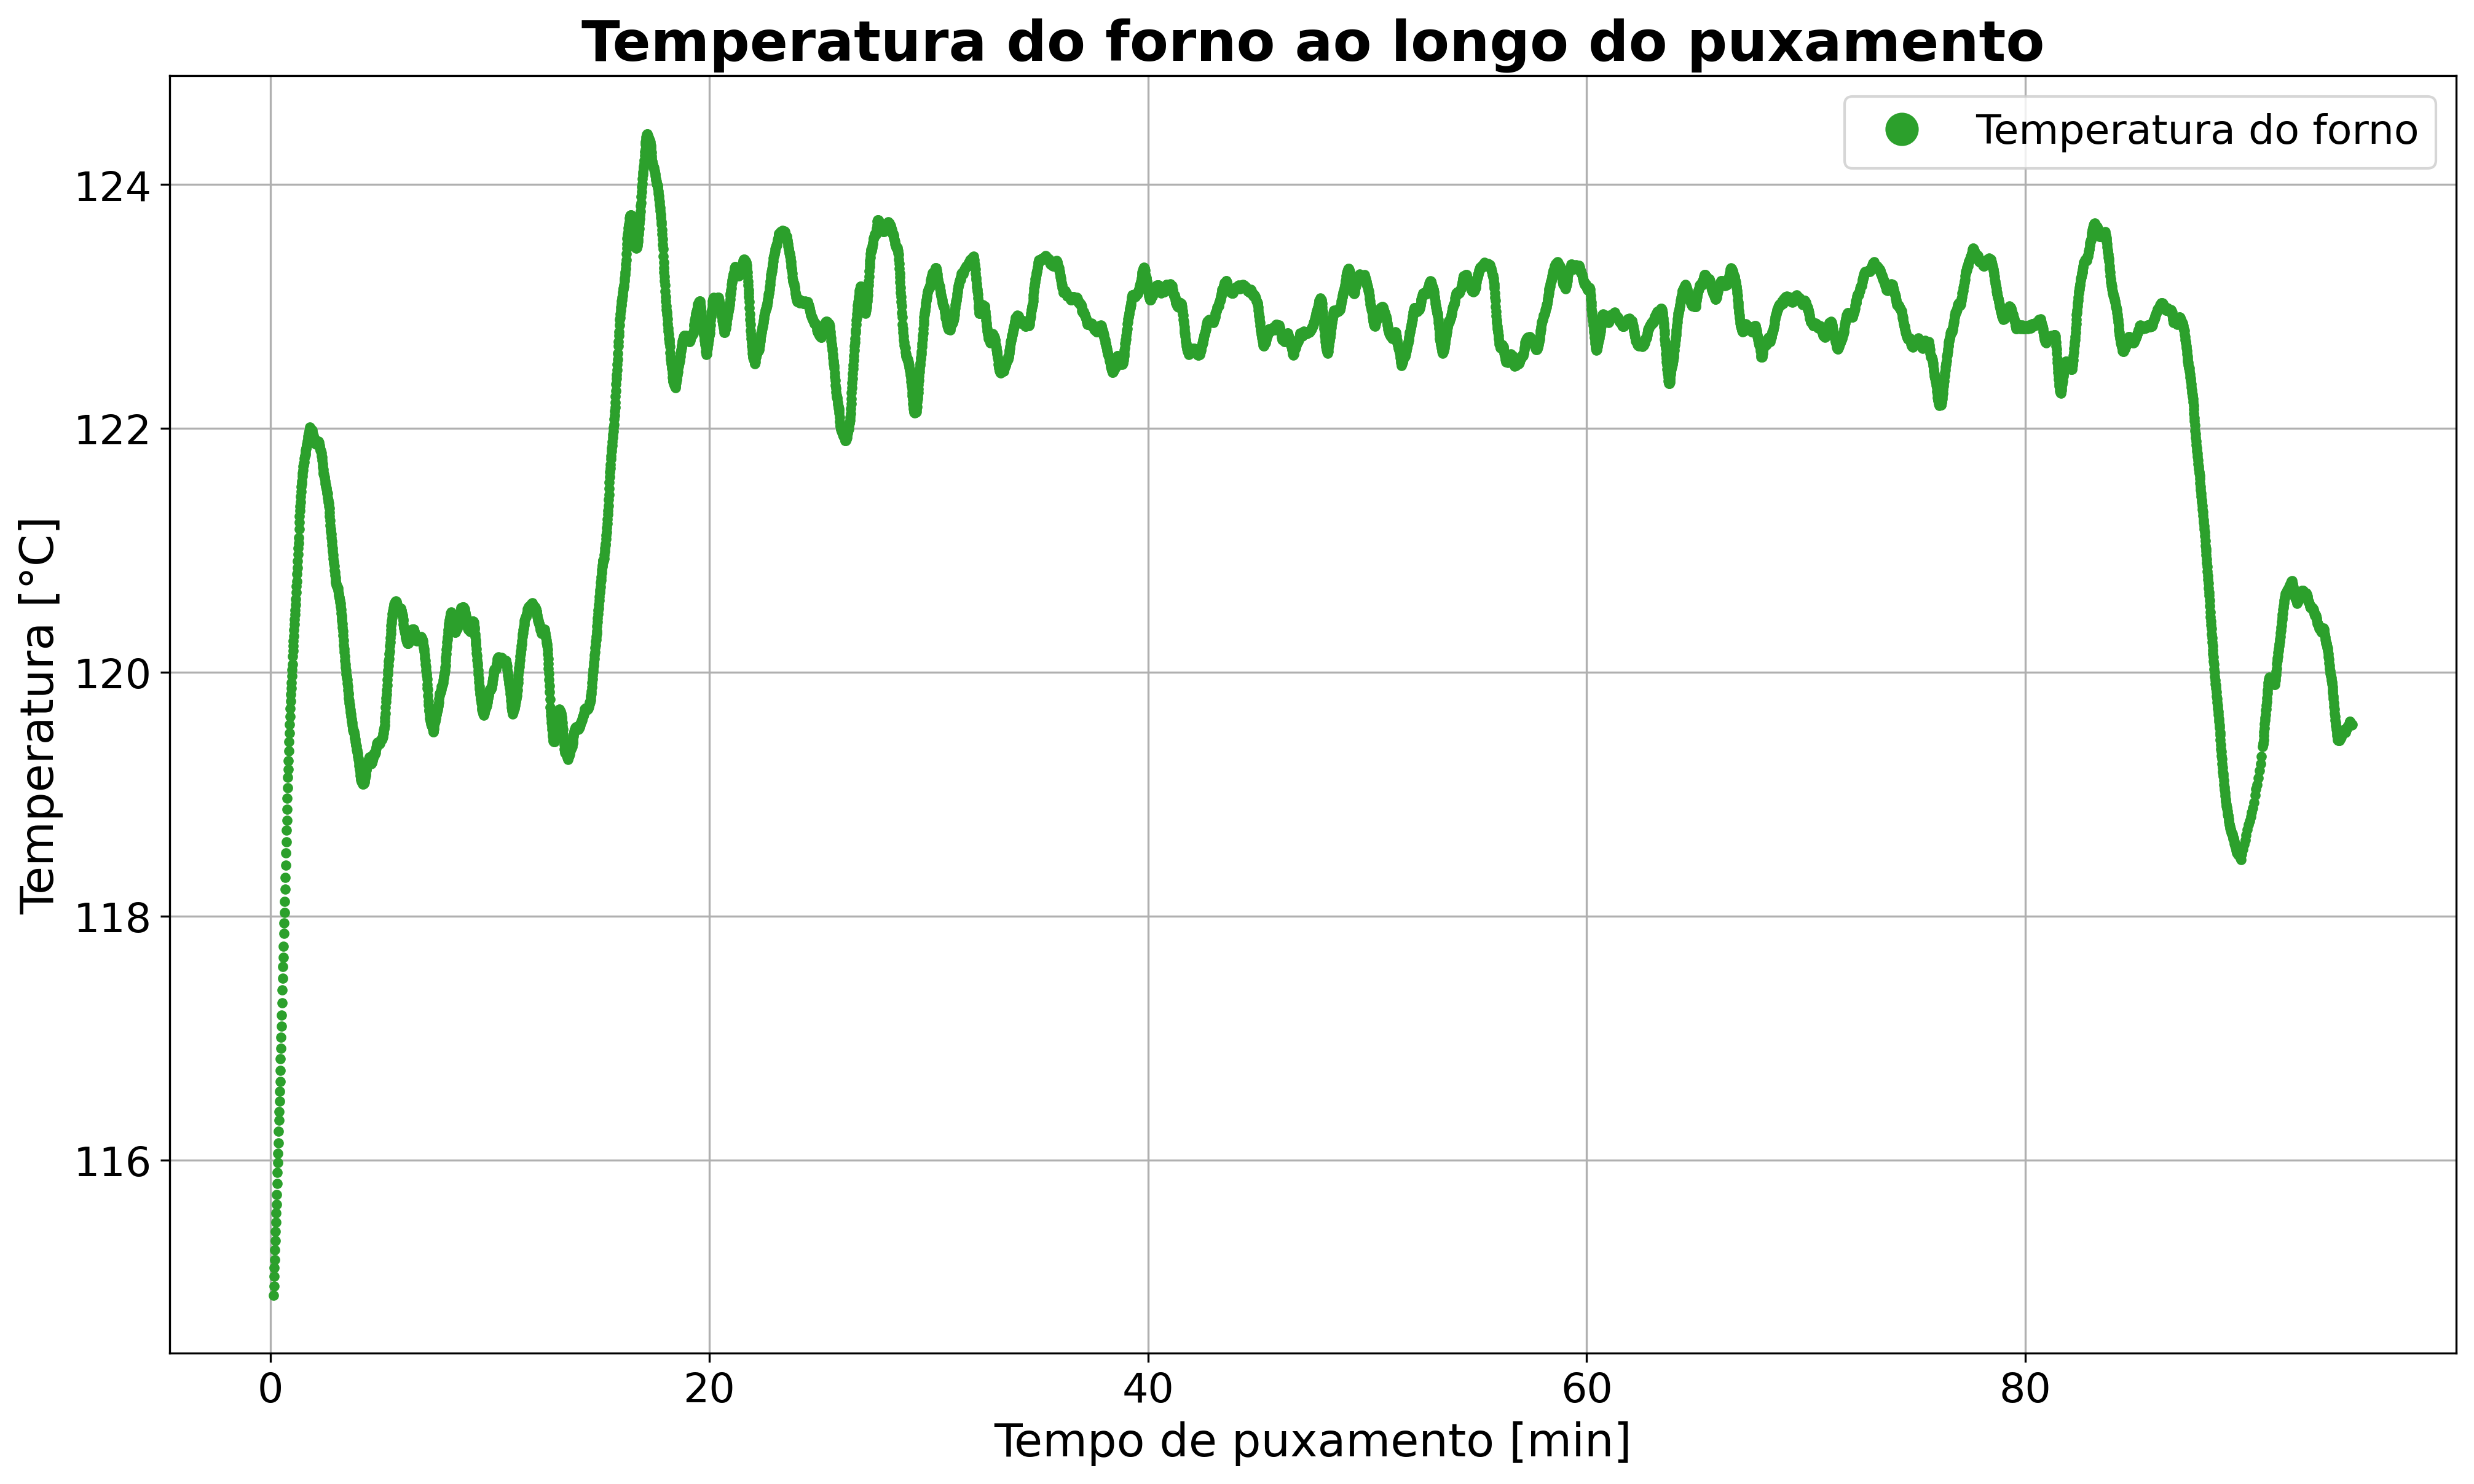

In [9]:
fig = plt.figure(figsize=(16,9), dpi=300)
ax = fig.add_axes(111)

temperatura_movel = media_movel(puxamento['Temperature'])
ax.plot(tempo_media_movel, temperatura_movel, '.',
            c='tab:green',
            label="Temperatura do forno")


if len(mudancas_temperatura):
    mudancas_temperatura = np.array(mudancas_temperatura)+puxamento.iloc[0]['Time']
    ax.vlines(mudancas_temperatura,
                ymin=min_temp, ymax=max_temp,
                colors='k', linestyles='dashed',
                label='Mudanças de temperatura')


ax.set_ylabel("Temperatura [°C]", fontdict=axis_fontdict)
ax.set_xlabel("Tempo de puxamento [min]", fontdict=axis_fontdict)
ax.set_title("Temperatura do forno ao longo do puxamento",
              fontdict=title_fontdict)
ax.grid()
ax.legend(markerscale=4)

fig.savefig(join(pasta_imagens, "Temperatura.png"), dpi=200)

plt.show()

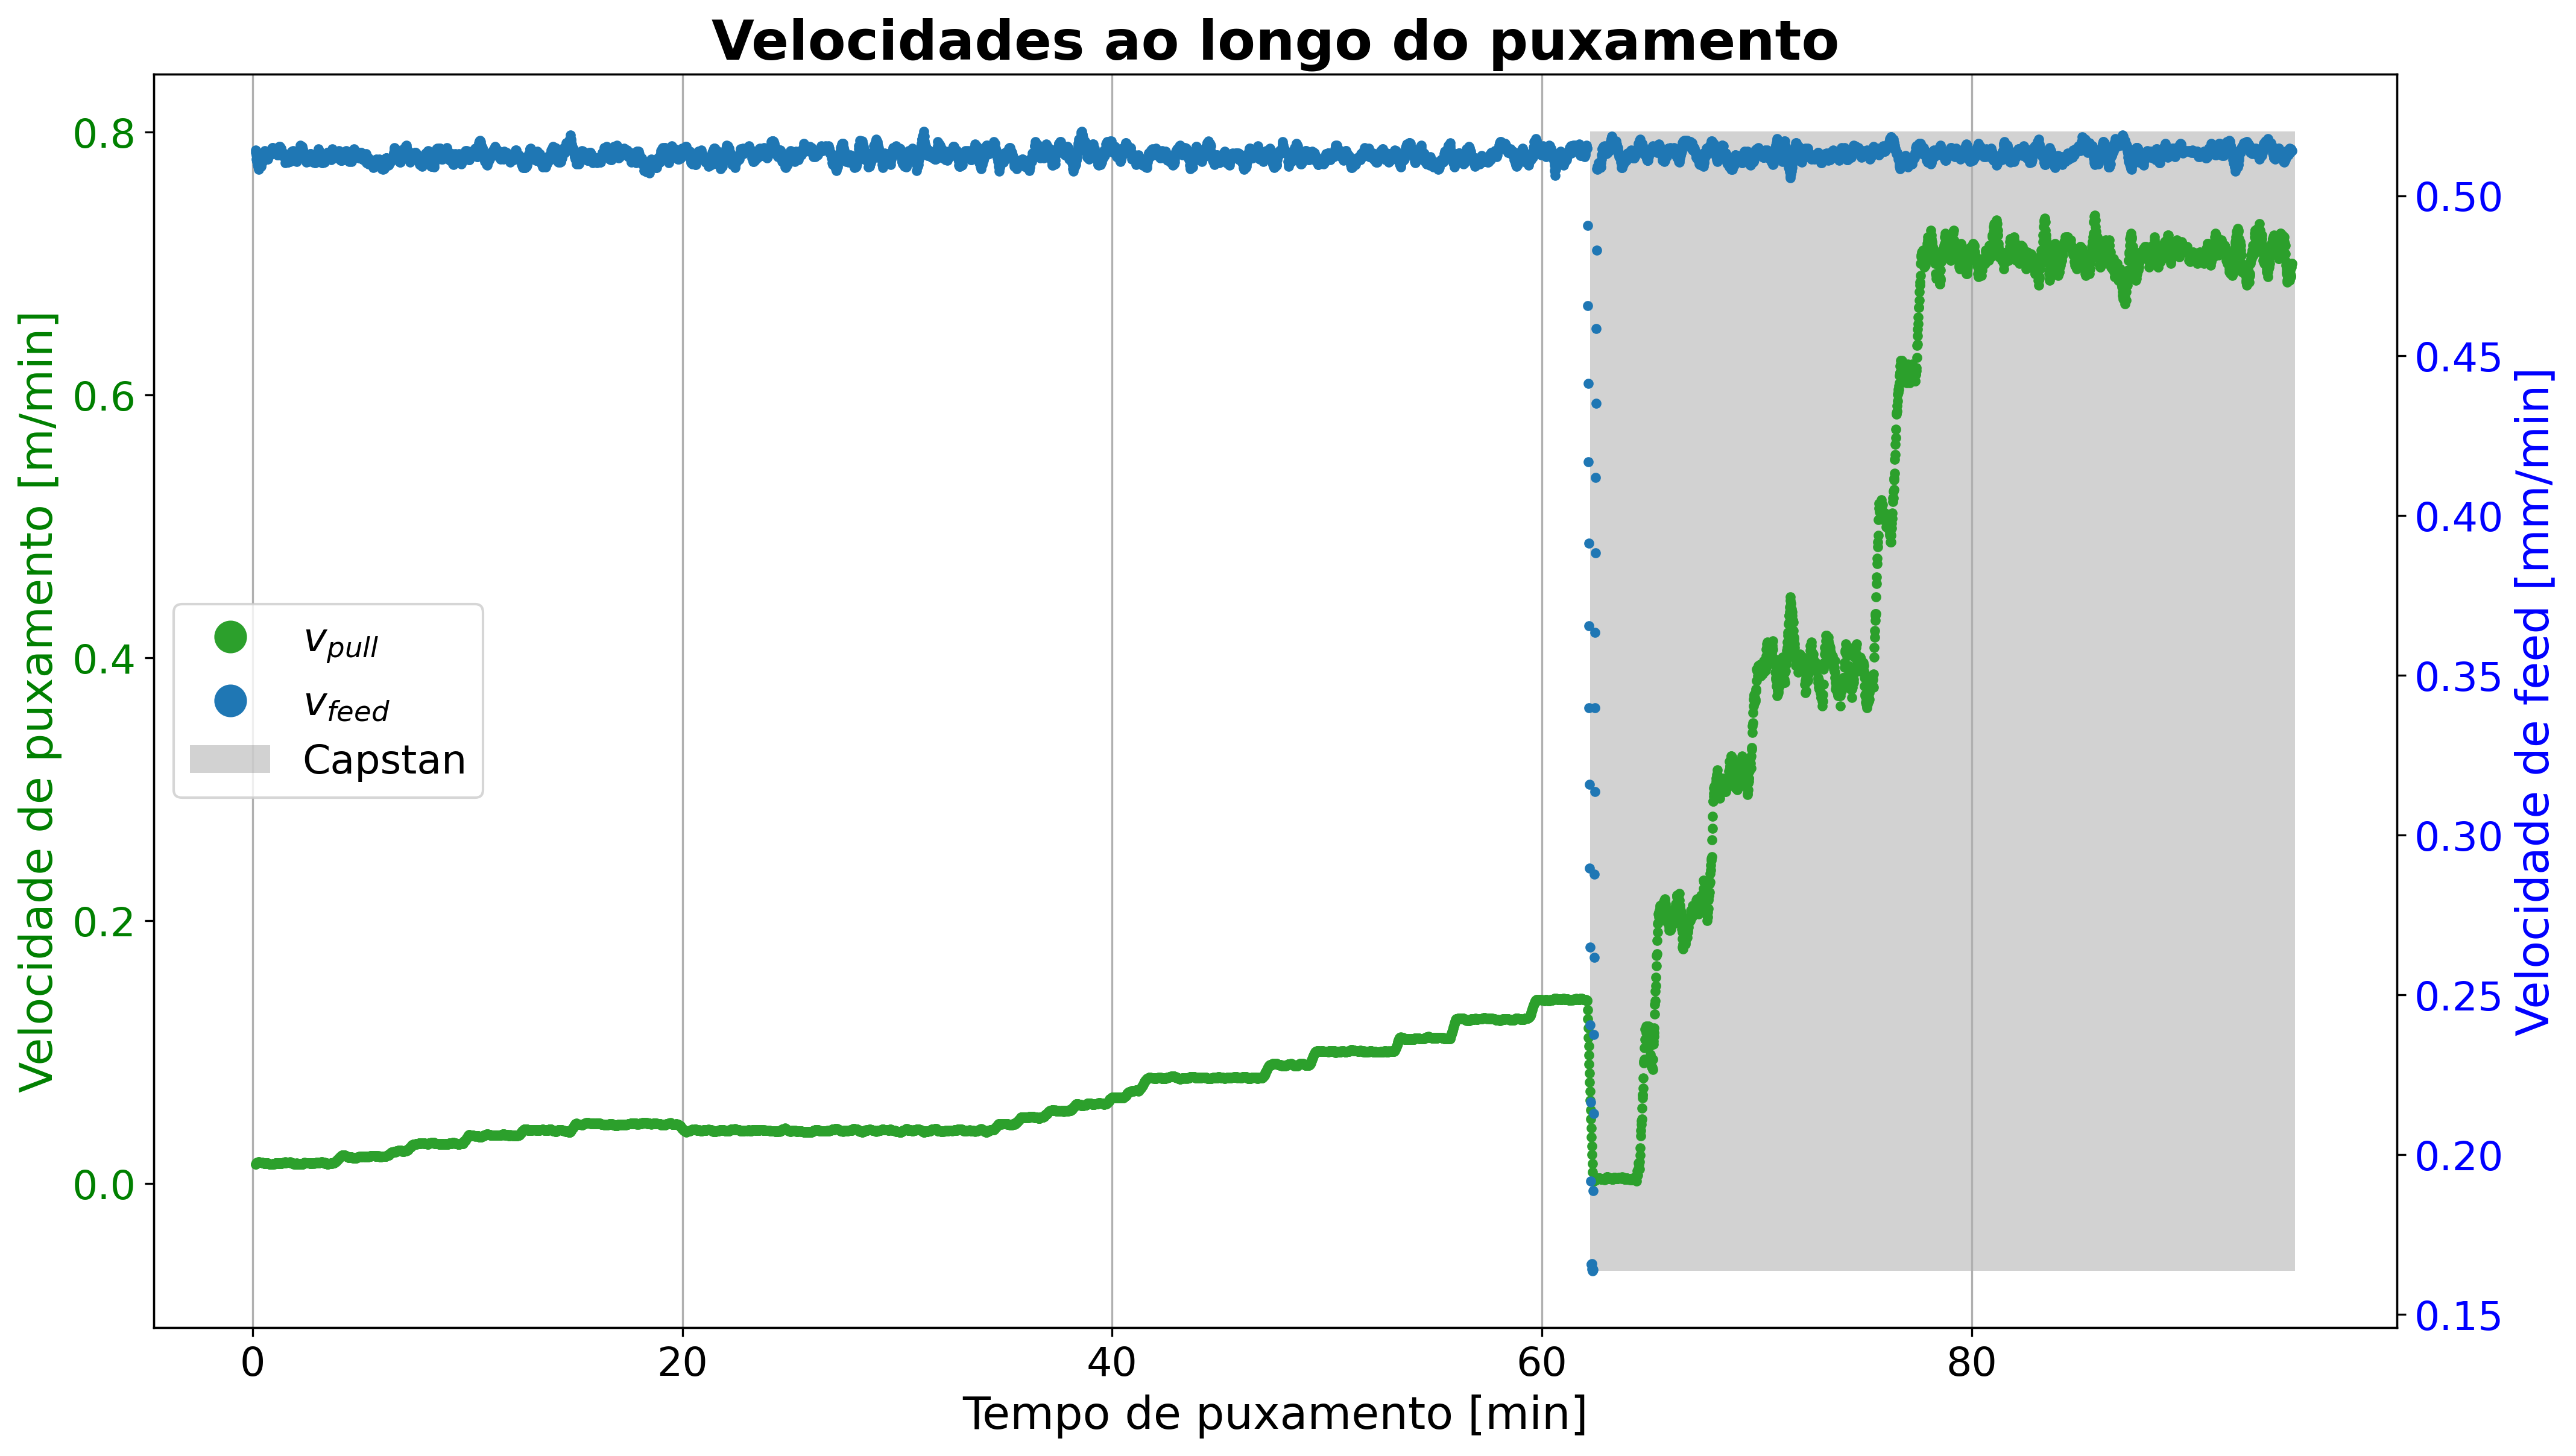

In [10]:
fig = plt.figure(figsize=(16,9), dpi=300)
ax = fig.add_axes(111)

velocidade_pull = media_movel(puxamento['Tractor Speed'])
velocidade_feed = media_movel(puxamento['Preform feed rate'])

p_pull, = ax.plot(tempo_media_movel, velocidade_pull, '.',
                c='tab:green',
                label=r"$v_{pull}$")


p_capstan = ax.fill_between([tempo_capstan, duracao_puxamento],
                            y1=min_vel_capstan, y2=max_vel_capstan,
                            facecolor='grey', alpha=0.35, label='Capstan')


ax2 = ax.twinx()
p_feed, = ax2.plot(tempo_media_movel, velocidade_feed, '.',
                c='tab:blue',
                label=r"$v_{feed}$")



ax.set_ylabel("Velocidade de puxamento [m/min]",
                fontdict=axis_fontdict, color='g')
ax.tick_params(axis='y', labelcolor='g')


ax2.set_ylabel('Velocidade de feed [mm/min]',
                fontdict=axis_fontdict, color='b')
ax2.tick_params(axis='y', labelcolor='b')


ax.grid(axis='x')
ax.set_xlabel("Tempo de puxamento [min]", fontdict=axis_fontdict)
ax.set_title("Velocidades ao longo do puxamento",
              fontdict=title_fontdict)

ax.legend(handles=[p_pull, p_feed, p_capstan],
          markerscale=4, loc='center left')


fig.savefig(join(pasta_imagens, "Velocidades.png"), dpi=200)
plt.show()

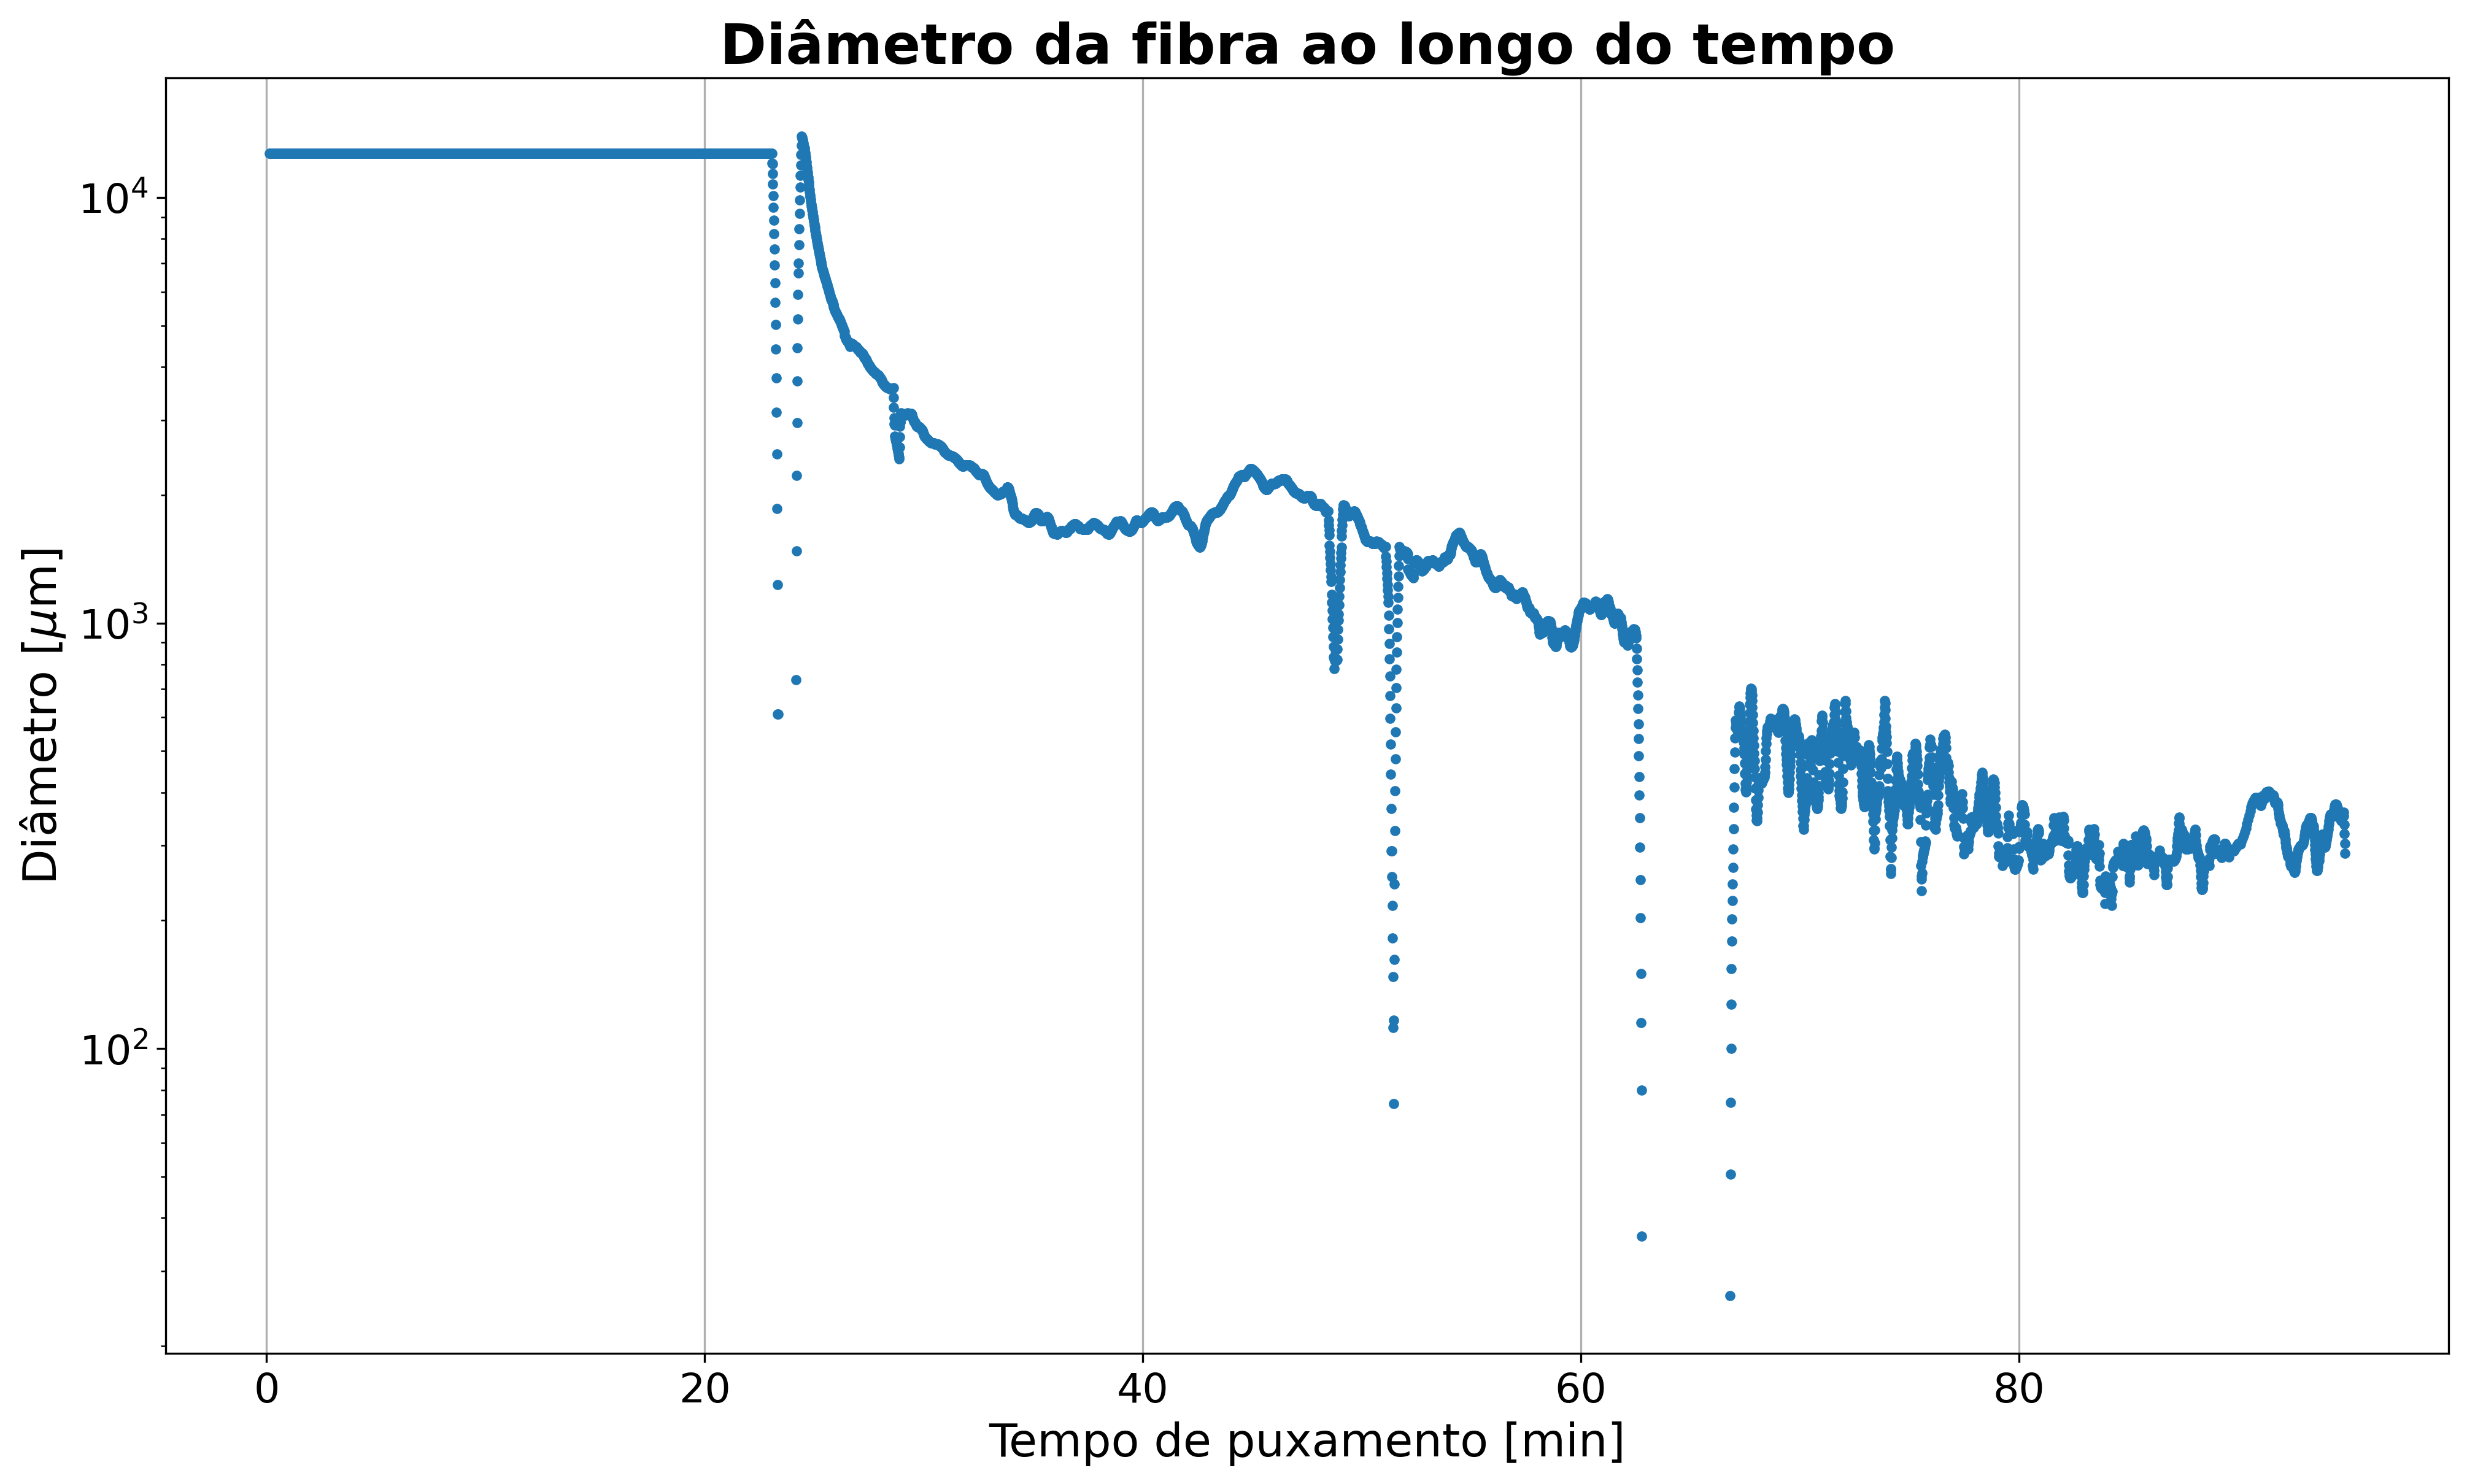

In [11]:
fig = plt.figure(figsize=(16,9), dpi=300)
ax = fig.add_axes(111)

diametro_movel = media_movel(puxamento['Diameter'])

p_diam, = ax.plot(tempo_media_movel, diametro_movel, '.',
                    c='tab:blue', label='Diâmetro')

ax.set_ylabel(r"Diâmetro [$\mu$m]",
              fontdict=axis_fontdict)
ax.tick_params(axis='y')
ax.set_yscale('log')
ax.set_yticks([1e2, 1e3, 1e4])


ax.grid(axis='x')
ax.set_xlabel("Tempo de puxamento [min]", fontdict=axis_fontdict)
ax.set_title("Diâmetro da fibra ao longo do tempo",
              fontdict=title_fontdict)

fig.savefig(join(pasta_imagens, "Diametro.png"), dpi=200)
plt.show()

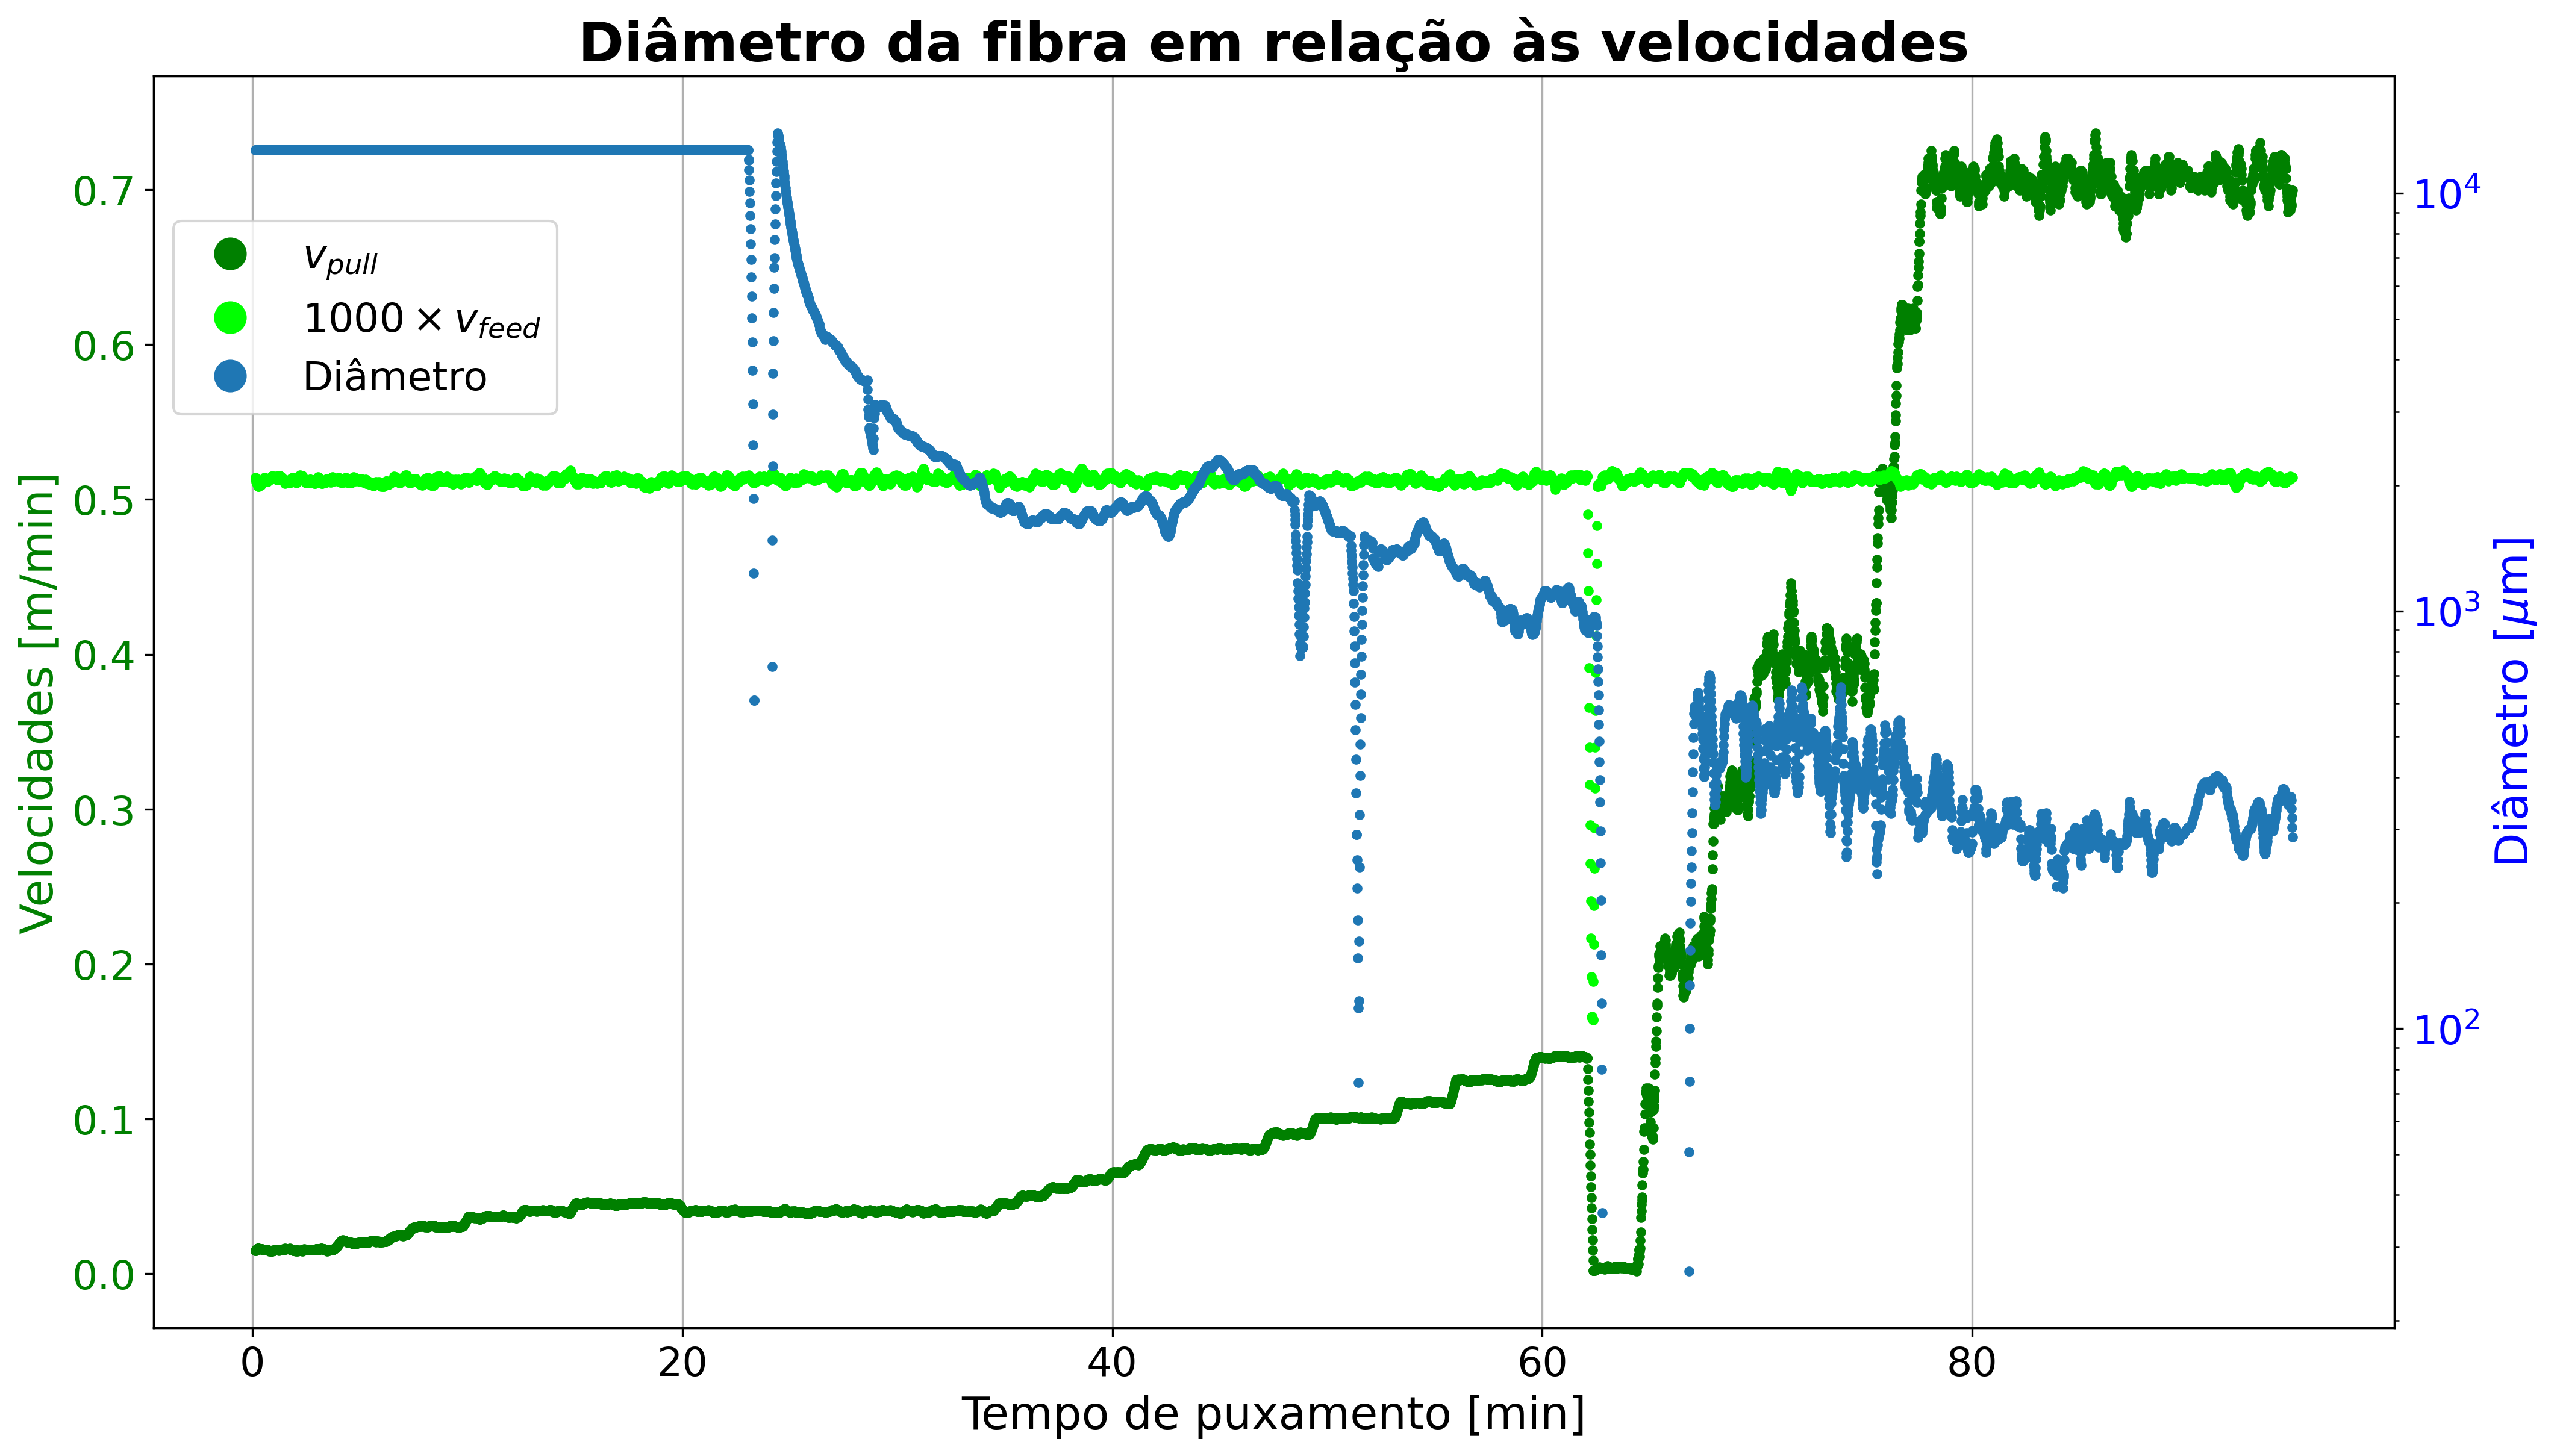

In [23]:
fig = plt.figure(figsize=(16,9), dpi=300)
ax = fig.add_axes(111)

diametro_movel = media_movel(puxamento['Diameter'])

p_pull, = ax.plot(tempo_media_movel, velocidade_pull, '.',
                c='green',
                label=r"$v_{pull}$")

p_feed, = ax.plot(tempo_media_movel, velocidade_feed, '.',
                c='lime',
                label=r"$1000\times v_{feed}$")

ax2 = ax.twinx()
p_diam, = ax2.plot(tempo_media_movel, diametro_movel, '.',
                    c='tab:blue', label='Diâmetro')

ax.set_ylabel("Velocidades [m/min]",
                fontdict=axis_fontdict, color='g')
ax.tick_params(axis='y', labelcolor='g')


ax2.set_ylabel(r"Diâmetro [$\mu$m]",
                fontdict=axis_fontdict, color='b')
ax2.tick_params(axis='y', labelcolor='b')
ax2.set_yscale('log')
ax2.set_yticks([1e2, 1e3, 1e4])


ax.grid(axis='x')
ax.set_xlabel("Tempo de puxamento [min]", fontdict=axis_fontdict)
ax.set_title("Diâmetro da fibra em relação às velocidades",
              fontdict=title_fontdict)

ax.legend(handles=[p_pull, p_feed, p_diam],
          loc='upper left',
          bbox_to_anchor=(0,0.9),
          markerscale=4)


fig.savefig(join(pasta_imagens, "Velocidade_e_diametro.png"), dpi=200)
plt.show()

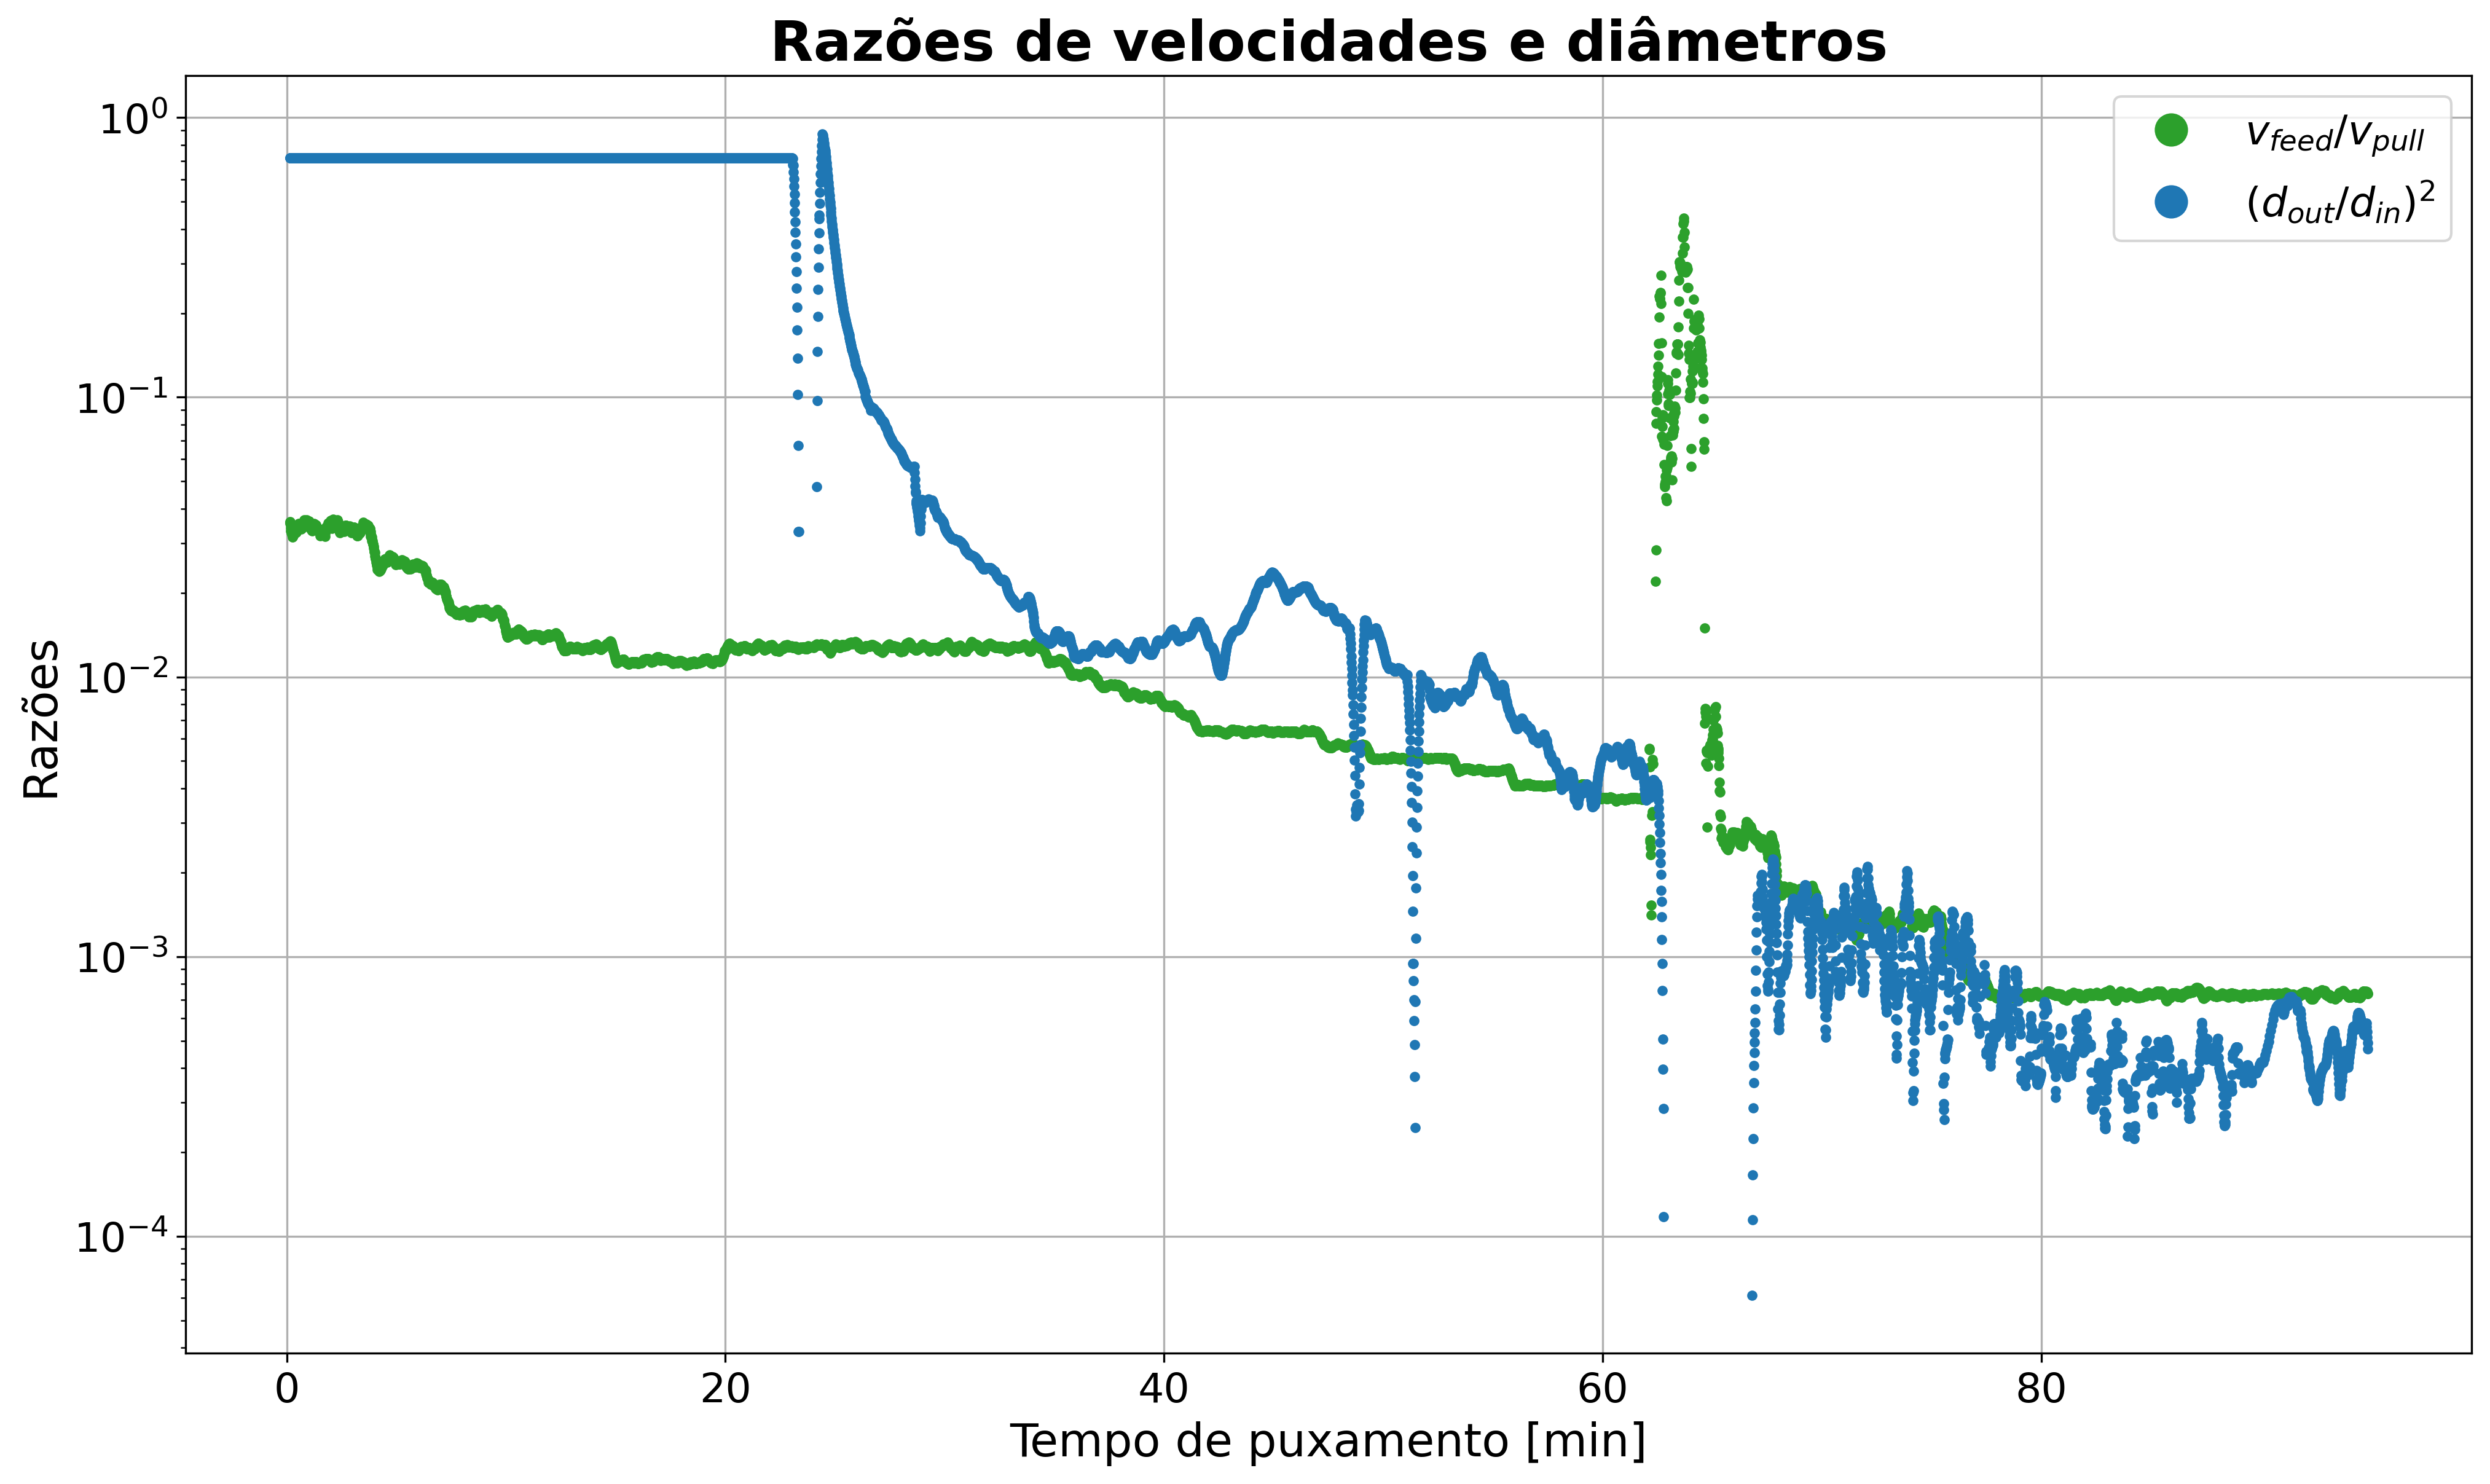

In [24]:
fig = plt.figure(figsize=(16,9), dpi=300)
ax = fig.add_axes(111)

razao_diam2 = ( puxamento['Diameter']*1e-3 / diametro_inicial )**2
razao_vel = puxamento['Preform feed rate']*1e-3 / puxamento['Tractor Speed']

razao_diam2_movel = media_movel(razao_diam2)
razao_vel_movel = media_movel(razao_vel)

p_vel, = ax.plot(tempo_media_movel, razao_vel_movel, '.',
                c='tab:green',
                label=r"$v_{feed}/v_{pull}$")

p_diam, = ax.plot(tempo_media_movel, razao_diam2_movel, '.',
                    c='tab:blue', label=r"$(d_{out}/d_{in})^2$")

ax.set_ylabel("Razões", fontdict=axis_fontdict)
ax.tick_params(axis='y')


ax.grid()
ax.set_xlabel("Tempo de puxamento [min]", fontdict=axis_fontdict)
ax.set_title("Razões de velocidades e diâmetros",
              fontdict=title_fontdict)
ax.set_yscale('log')

ax.legend(handles=[p_vel, p_diam],
          markerscale=4)


fig.savefig(join(pasta_imagens, "Razoes_vel_e_diam.png"), dpi=200)
plt.show()

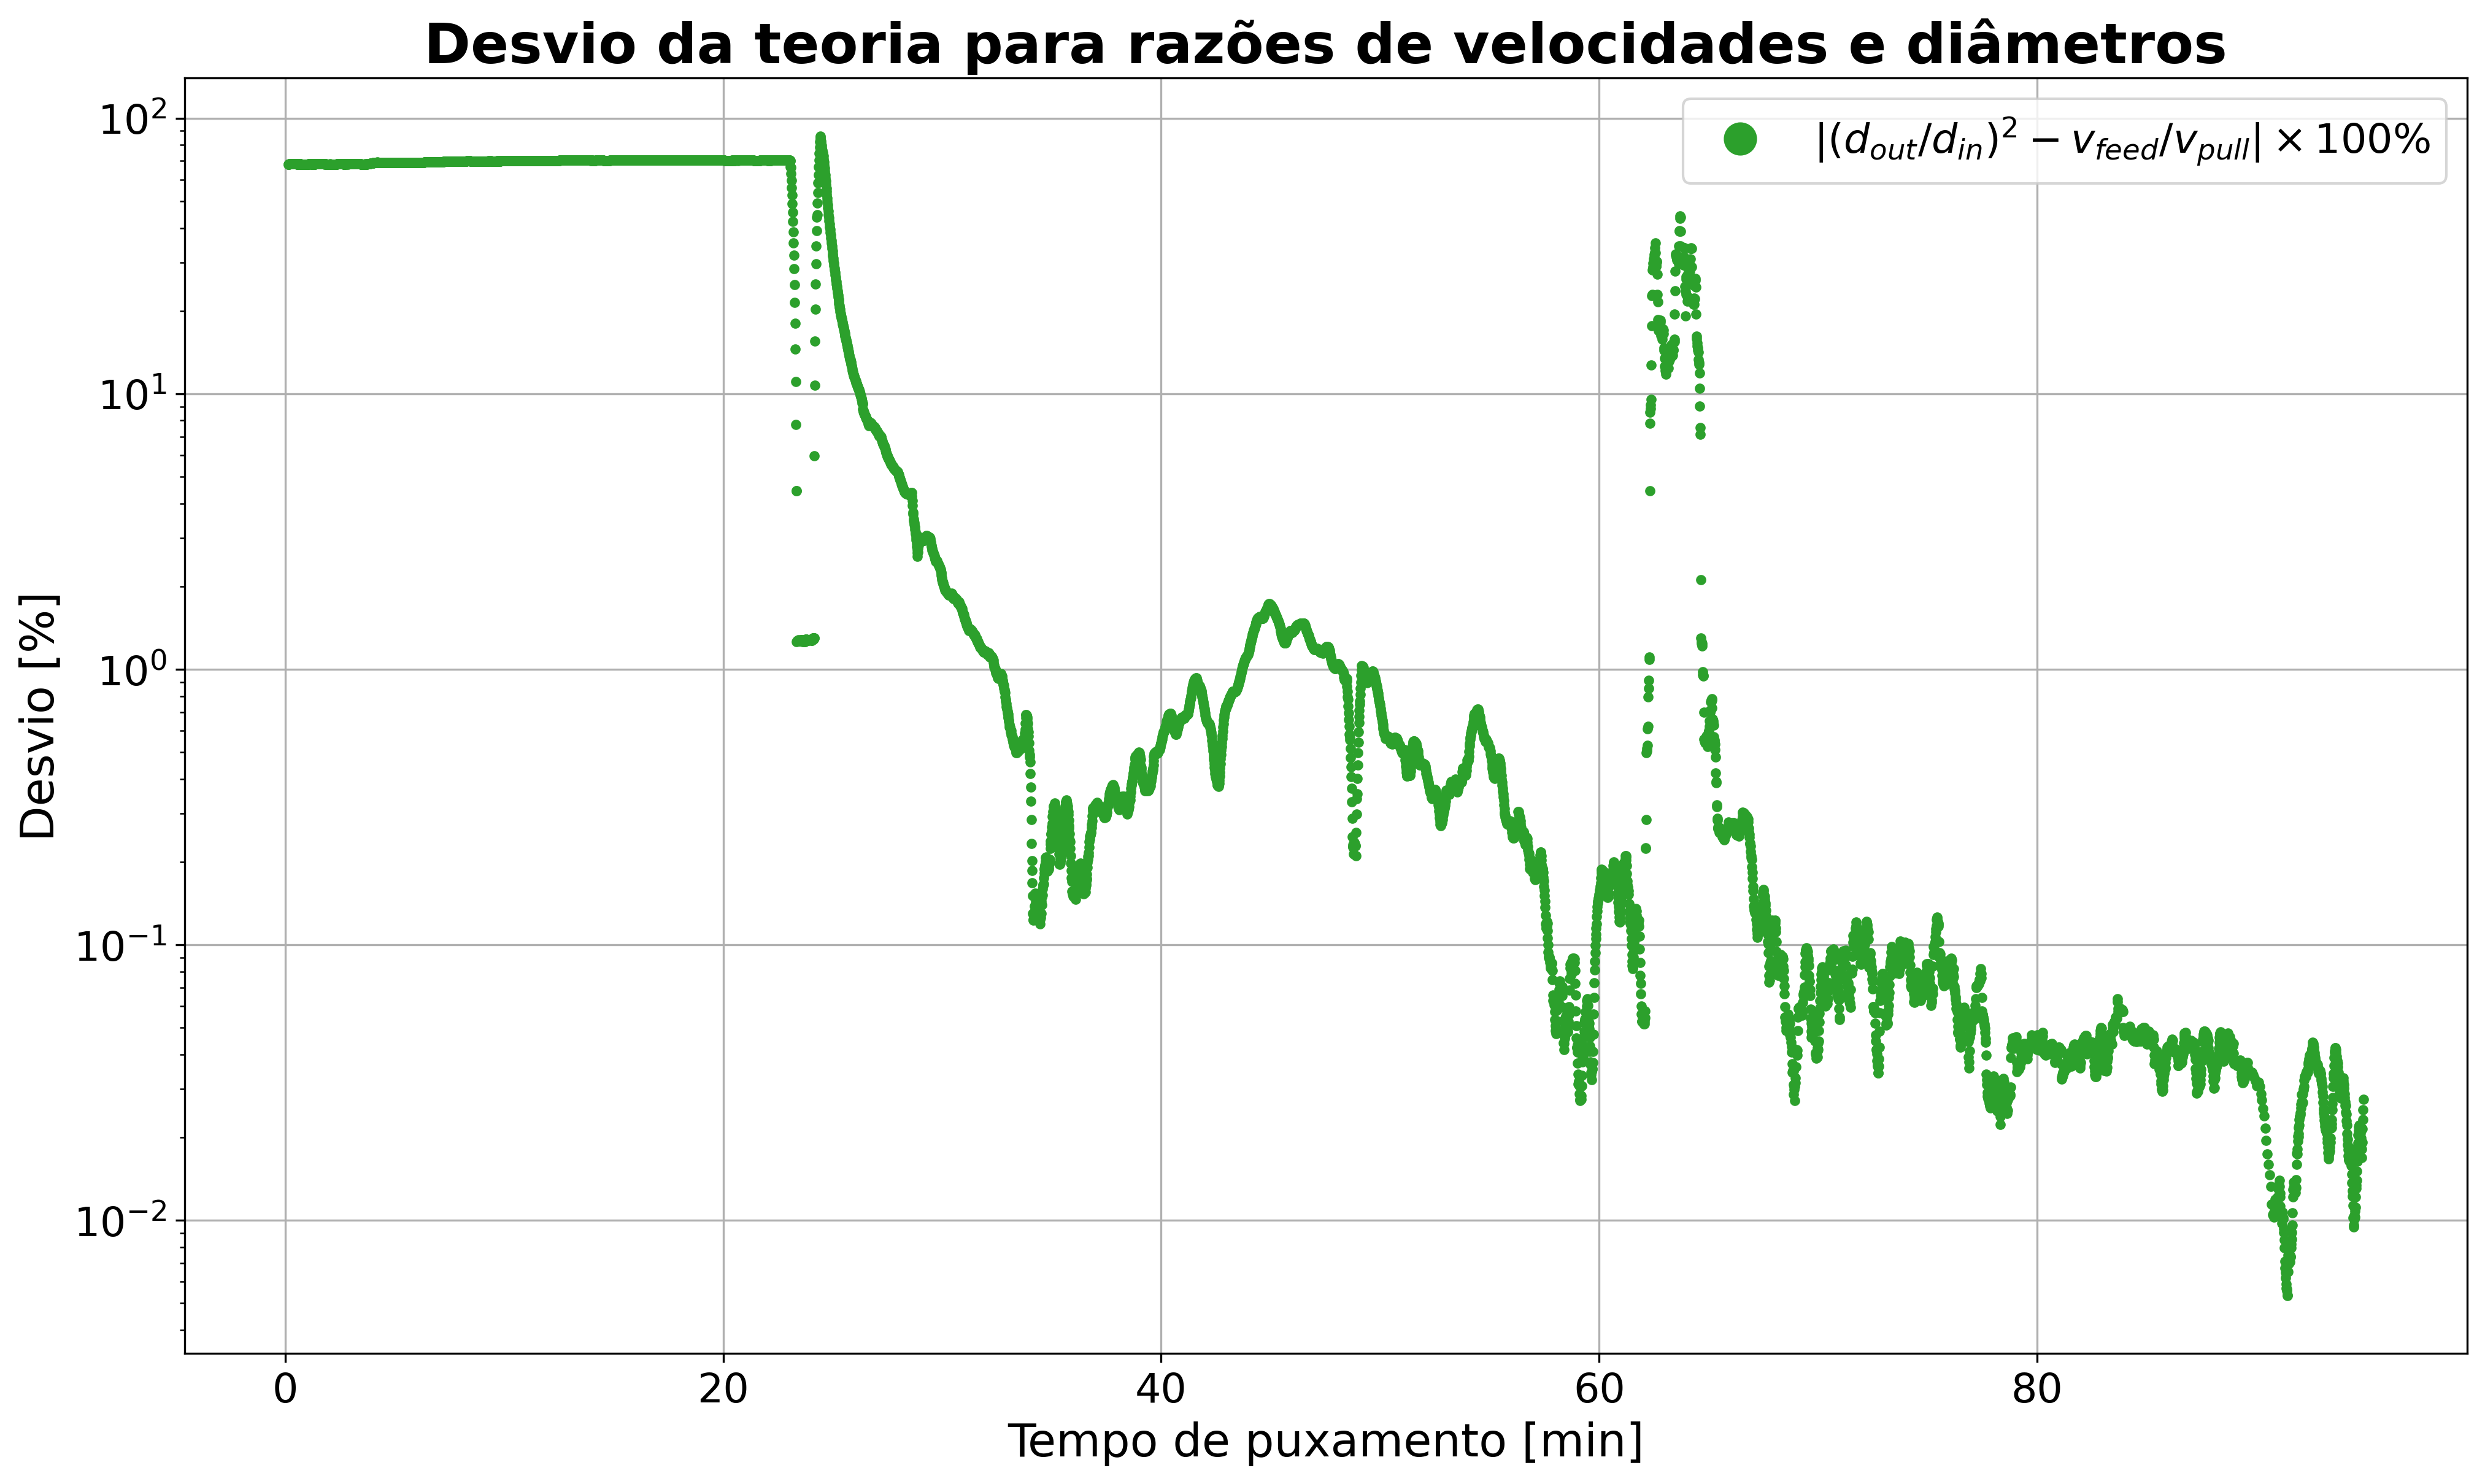

In [25]:
fig = plt.figure(figsize=(16,9), dpi=300)
ax = fig.add_axes(111)

razao_diam2 = ( puxamento['Diameter']*1e-3 / diametro_inicial )**2
razao_vel = puxamento['Preform feed rate']*1e-3 / puxamento['Tractor Speed']
desvio = np.abs(razao_diam2 - razao_vel)*100

desvio_movel = media_movel(desvio)

p, = ax.plot(tempo_media_movel, desvio_movel, '.',
                c='tab:green',
                label=r"$|(d_{out}/d_{in})^2-v_{feed}/v_{pull}|\times 100\%$")

ax.set_ylabel("Desvio [%]", fontdict=axis_fontdict)
ax.tick_params(axis='y')


ax.grid()
ax.set_xlabel("Tempo de puxamento [min]", fontdict=axis_fontdict)
ax.set_title("Desvio da teoria para razões de velocidades e diâmetros",
              fontdict=title_fontdict)
ax.set_yscale('log')

ax.legend(handles=[p],
          markerscale=4)


fig.savefig(join(pasta_imagens, "Desvio_vel_e_diam.png"), dpi=200)
plt.show()